# JSS Systematic Literature Review Data Analysis
This notebook shows how to use litstudy from inside a Jupyter notebook. It shows how to load a dataset, plot statistics, perform topic modeling, do network analysis, and some more advanced features.

This notebook focuses on the topic of SECO for SECO developing.

# Imports Selected Studies

In [1]:
# Import other libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbs
import re

# Options for plots
plt.rcParams['figure.figsize'] = (10, 6)
sbs.set('paper')

# Import litstudy
path = os.path.abspath(os.path.join('..'))
if path not in sys.path:
    sys.path.append(path)

import litstudy

In [2]:
from datetime import datetime

currentDateAndTime = datetime.now()
filename = (f'SOTA_SECO_CPS_{currentDateAndTime.year}-{currentDateAndTime.month}-{currentDateAndTime.day}'
            f'_{currentDateAndTime.hour}-{currentDateAndTime.minute}-{currentDateAndTime.second}')
filename_xlsx = (f'SOTA_SECO_CPS_{currentDateAndTime.year}-{currentDateAndTime.month}-{currentDateAndTime.day}'
            f'_{currentDateAndTime.hour}-{currentDateAndTime.minute}-{currentDateAndTime.second}.xlsx')

print(filename)

SOTA_SECO_CPS_2025-5-15_11-7-15


In [18]:
############################## LOAD Cleaned papers ###################################

# with open('AAA/studies.txt', 'r') as file:
#     data = file.read().splitlines()
#     print(data)
    
# Load csv file
docs_bib = litstudy.load_scopus_csv('Results/Final-Selected-Primary-Studies.csv')
print(len(docs_bib), 'papers loaded from selected papers list')

23 papers loaded from selected papers list


In [20]:
import logging
logging.getLogger().setLevel(logging.CRITICAL)

docs_found_scopus, docs_notfound_scopus = litstudy.refine_scopus(docs_bib)

100%|██████████| 23/23 [00:00<00:00, 352.41it/s]


In [22]:
print(len(docs_found_scopus), 'papers found on Scopus')
print(len(docs_notfound_scopus), 'papers were not found')
docs_bib_scopus = docs_found_scopus | docs_notfound_scopus
len(docs_bib_scopus)

23 papers found on Scopus
0 papers were not found


23

In [24]:
docs_bib2 = litstudy.search_scopus("10.1109/CloudCom.2014.158")
print(len(docs_bib2), 'papers loaded from selected papers list')

100%|██████████| 1/1 [00:00<00:00, 504.97it/s]

1 papers loaded from selected papers list


In [26]:
docs_bib = docs_bib2 | docs_found_scopus

In [28]:
# docs_bib = docs_bib_scopus # docs_bib_scopus | docs_bib_SemanticScholar | docs_bib_CrossRef
docs_filtered = docs_bib # .filter_docs(lambda d: d.publication_year >= 1990)

# Selected Paper Analysis
Litstudy analysis

      Frequency
2009          1
2010          0
2011          1
2012          0
2013          0
2014          3
2015          0
2016          1
2017          2
2018          3
2019          3
2020          1
2021          2
2022          3
2023          2
2024          2


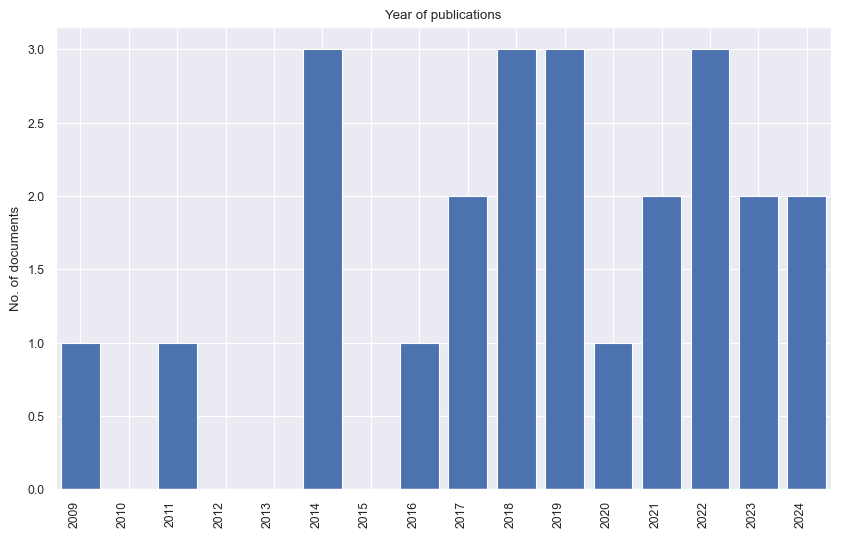

In [31]:
pdStatYear = litstudy.stats.compute_year_histogram(docs_filtered)
print(pdStatYear)

#plt.figure(1)
litstudy.plot_year_histogram(docs_filtered, vertical=True);
#plt.xticks(fontsize=12)
#plt.yticks(fontsize=12)
#plt.title('')
plt.grid(True)
plt.savefig('Results/SOTA_SECO_CPS_2025-4-17_11-4-34_Analysis_Final/' + str(filename) + '_01_plot_year_histogram.png', dpi=300, bbox_inches='tight', format="PNG")

    index  Frequency Journal Conference Workshop Book Symposium Forum
0    2009          1       0          1        0    0         0     0
1    2010          0       0          0        0    0         0     0
2    2011          1       1          0        0    0         0     0
3    2012          0       0          0        0    0         0     0
4    2013          0       0          0        0    0         0     0
5    2014          3       2          1        0    0         0     0
6    2015          0       0          0        0    0         0     0
7    2016          1       1          0        0    0         0     0
8    2017          2       1          1        0    0         0     0
9    2018          3       2          1        0    0         0     0
10   2019          3       3          0        0    0         0     0
11   2020          1       0          1        0    0         0     0
12   2021          2       2          0        0    0         0     0
13   2022          3

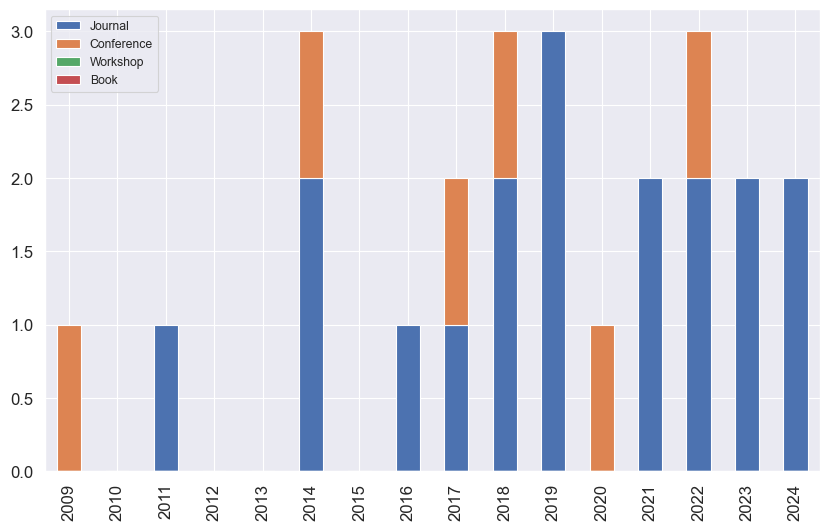

In [33]:
pdStatYear = litstudy.stats.compute_year_histogram(docs_filtered)
# print(pdStatYear)
pdStatYear["Journal"] = ""
pdStatYear["Conference"] = ""
pdStatYear["Workshop"] = ""
pdStatYear["Book"] = ""
pdStatYear["Symposium"] = ""
pdStatYear["Forum"] = ""
#for ind in pdStatYear.index:
#    print(pdStatYear[][ind], df['Frequency'][ind])
pdStatYear2 = pdStatYear.reset_index()
# print(pdStatYear2)
#df2 = pdStatYear2[pdStatYear2.columns[0]]
# print(pdStatYear2["index"][3])

# loop through the rows using iterrows()
for index, row in pdStatYear2.iterrows():
    # print(row['index'], row['Frequency'])
    
    docs_journal = docs_bib.filter_docs(lambda d: (d.source_type == 'Journal'  or d.id.doi == '10.1007/978-3-319-46508-1_13') 
                                        and d.publication_year == row['index'])
    # print(len(docs_journal))
    pdStatYear2.loc[index,'Journal'] = len(docs_journal)
    
    pattern_conf = ['conference','symposium','lecture notes','congress','Design, Automation and Test in Europe']
    docs_conf = docs_bib.filter_docs(lambda d: (d.source_type == 'Conference Proceeding' or d.source_type == 'Book Series' or 
                                      d.id.doi == '10.24251/HICSS.2017.569') and d.publication_year == row['index'] and
                                     (not d.id.doi == '10.1007/978-3-319-46508-1_13') and
                                     ( re.search(pattern_conf[0],str(d.publication_source),re.IGNORECASE) or 
                                       re.search(pattern_conf[1],str(d.publication_source),re.IGNORECASE) or 
                                       re.search(pattern_conf[2],str(d.publication_source),re.IGNORECASE) or
                                       re.search(pattern_conf[4],str(d.publication_source),re.IGNORECASE)  or
                                       re.search('studies',str(d.publication_source),re.IGNORECASE) or
                                        docs_filtered[index].id.doi == '10.1007/978-3-031-16088-2_4' or
                                        docs_filtered[index].id.doi == '10.1109/DEST.2010.5610662' or
                                       re.search('Event-Driven Interoperable Manufacturing Ecosystem for Energy Consumption Monitoring',str(docs_filtered[index].title),re.IGNORECASE) or
                                       re.search('forum',str(d.publication_source),re.IGNORECASE) ) and
                                       (not re.search('workshop',str(d.publication_source),re.IGNORECASE)) and
                                       (not re.search('companion',str(d.publication_source),re.IGNORECASE)) and
                                       (not re.search('MODELS-C',str(d.publication_source),re.IGNORECASE)) and
                                       (not re.search('ICSA-C',str(d.publication_source),re.IGNORECASE)) )
    # print(len(docs_conf))  
    pdStatYear2.loc[index,'Conference'] = len(docs_conf)
    
    doc_workshop = docs_bib.filter_docs(lambda d: (d.source_type == 'Conference Proceeding' or d.source_type == 'Book Series' ) and 
                                            d.publication_year == row['index'] and 
                                            (not d.id.doi == '10.1007/978-3-319-46508-1_13') and
                                            (re.search('workshop',str(d.publication_source),re.IGNORECASE) or
                                             re.search('seminar',str(d.publication_source),re.IGNORECASE) or                                          
                                             re.search('2021 Design, Automation and Test in Europe Conference and Exhibition, DATE 2021',str(d.publication_source),re.IGNORECASE) or
                                             re.search('companion',str(d.publication_source),re.IGNORECASE) or 
                                             re.search('MODELS-C',str(d.publication_source),re.IGNORECASE) or 
                                             re.search('ICSA-C',str(d.publication_source),re.IGNORECASE) ) )
    
    # indexPP = 0
    # while indexPP < len(doc_workshop):
        # print(doc_workshop[indexPP].title)
        # print(doc_workshop[indexPP].source_type)
    #     indexPP += 1
    
    # print(len(doc_book_series))
    pdStatYear2.loc[index,'Workshop'] = len(doc_workshop)
    doc_book = docs_bib.filter_docs(lambda d: d.source_type == 'Book' and d.publication_year == row['index'])
    # print(len(doc_book))
    pdStatYear2.loc[index,'Book'] = len(doc_book)
    
    pattern_symp = ['symposium','']
    docs_symp = docs_bib.filter_docs(lambda d: (d.source_type == 'Conference Proceeding' or d.source_type == 'Book Series' or 
                                                d.id.doi == '10.24251/HICSS.2017.569')
                                     and d.publication_year == row['index'] and
                                     (not d.id.doi == '10.1007/978-3-319-46508-1_13') and
                                     re.search(pattern_symp[0],str(d.publication_source),re.IGNORECASE) and
                                     (not re.search('workshop',str(d.publication_source),re.IGNORECASE)) and
                                     (not re.search('conference',str(d.publication_source),re.IGNORECASE)) )
    # print(len(docs_conf))  
    pdStatYear2.loc[index,'Symposium'] = len(docs_symp)
                                     
    pattern_forum = ['forum','']
    docs_forum = docs_bib.filter_docs(lambda d: (d.source_type == 'Conference Proceeding' or d.source_type == 'Book Series' or 
                                                d.id.doi == '10.24251/HICSS.2017.569') and d.publication_year == row['index'] and
                                     (not d.id.doi == '10.1007/978-3-319-46508-1_13') and
                                     re.search(pattern_forum[0],str(d.publication_source),re.IGNORECASE) )
    # print(len(docs_conf))  
    pdStatYear2.loc[index,'Forum'] = len(docs_forum)
    
#
print(pdStatYear2)
print('\n')
print('Journal:',pdStatYear2['Journal'].sum())
print('Conference:',pdStatYear2['Conference'].sum())
print('Workshop:',pdStatYear2['Workshop'].sum())
print('Book:',pdStatYear2['Book'].sum())
print('Total:',pdStatYear2['Journal'].sum()+pdStatYear2['Conference'].sum()+pdStatYear2['Workshop'].sum()+pdStatYear2['Book'].sum())
print('\n')
print('Symposium:',pdStatYear2['Symposium'].sum())
print('Forum:',pdStatYear2['Forum'].sum())
print('\n')

# plt.figure(2)
# fig, ax = plt.subplots()
pdStatYear2.plot.bar(x='index', y=['Journal','Conference','Workshop','Book'], xlabel='', stacked=True)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title('')
plt.grid(True)

"""
plt.setp( ax.xaxis.get_majorticklabels(), rotation=90) 

# Create offset transform by 5 points in x direction
dx = 5/72.; dy = 0/72. 
offset = matplotlib.transforms.ScaledTranslation(dx, dy, fig.dpi_scale_trans)

# apply offset transform to all x ticklabels.
for label in ax.xaxis.get_majorticklabels():
    label.set_transform(label.get_transform() + offset)
"""

plt.savefig('Results/SOTA_SECO_CPS_2025-4-17_11-4-34_Analysis_Final/' + str(filename) + '_02_plot_year_type_histogram.png', dpi=300, bbox_inches='tight', format="PNG")

In [35]:
import re

index = 0
while index < len(docs_filtered):
    for author in docs_filtered[index].authors or []:
        re.sub(r'[\(\[].*?[\)\]]', '', str(author.name))
    index += 1

pdStatAuthors = litstudy.stats.compute_author_histogram(docs_filtered)

pdStatAuthors

,Frequency
Axelsson J. (AUID: 36613006300),2
Bosch J. (AUID: 56675290800),2
Ruiz-Cortés A. (AUID: 15120180100),2
Taherkordi A. (AUID: 14054944100),1
Lazkanoiturburu I. (AUID: 57220864456),1
...,...
Derguech W. (AUID: 38361290300),1
Curry E. (AUID: 12790805000),1
Skoglund M. (AUID: 56276682900),1
Mora L. (AUID: 57169939100),1


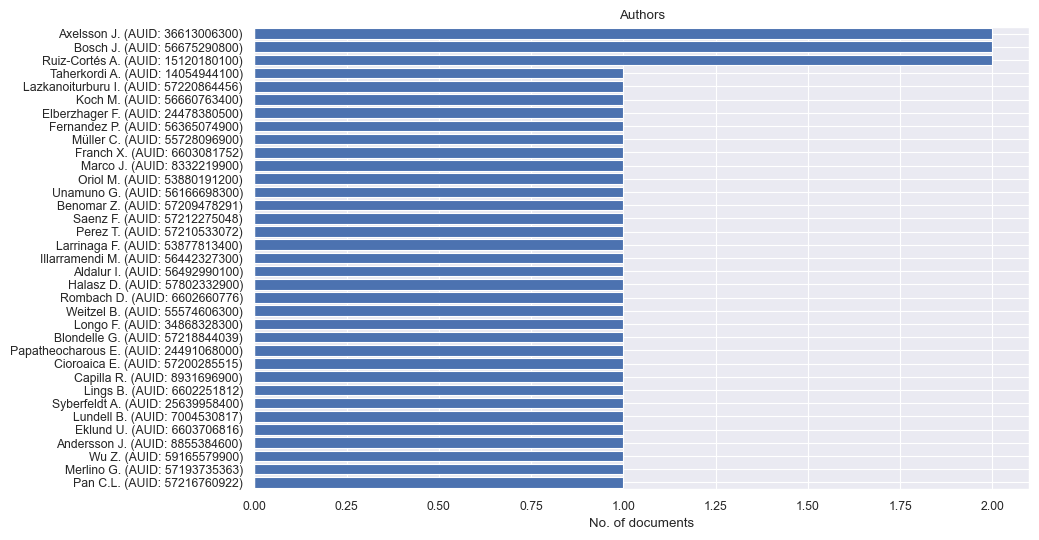

In [39]:
plt.figure(3)
litstudy.plot_author_histogram(docs_filtered, stacked=True, limit=35)
#plt.xticks(fontsize=12)
#plt.yticks(fontsize=12)
#plt.title('')
plt.grid(True)
plt.savefig('Results/SOTA_SECO_CPS_2025-4-17_11-4-34_Analysis_Final/' + str(filename) + '_03_plot_authors_histogram.png', dpi=300, bbox_inches='tight', format="PNG")

,Frequency
Journal of Systems and Software,5
Information and Software Technology,2
IEEE International Conference on Cloud Computing Technology and Science CloudCom,1
International Conference on Evaluation and Assessment in Software Engineering EASE,1
International Journal of Innovation Studies,1
IEEE Transactions on Network Science and Engineering,1
International Conference on Product Focused Software Process Improvement PROFES,1
Internet of Things Netherlands,1
Annual Conference of the IEEE Industrial Electronics Society IECON,1
Symposium on Software Engineering for Adaptive and Self Managing Systems SEAMS,1


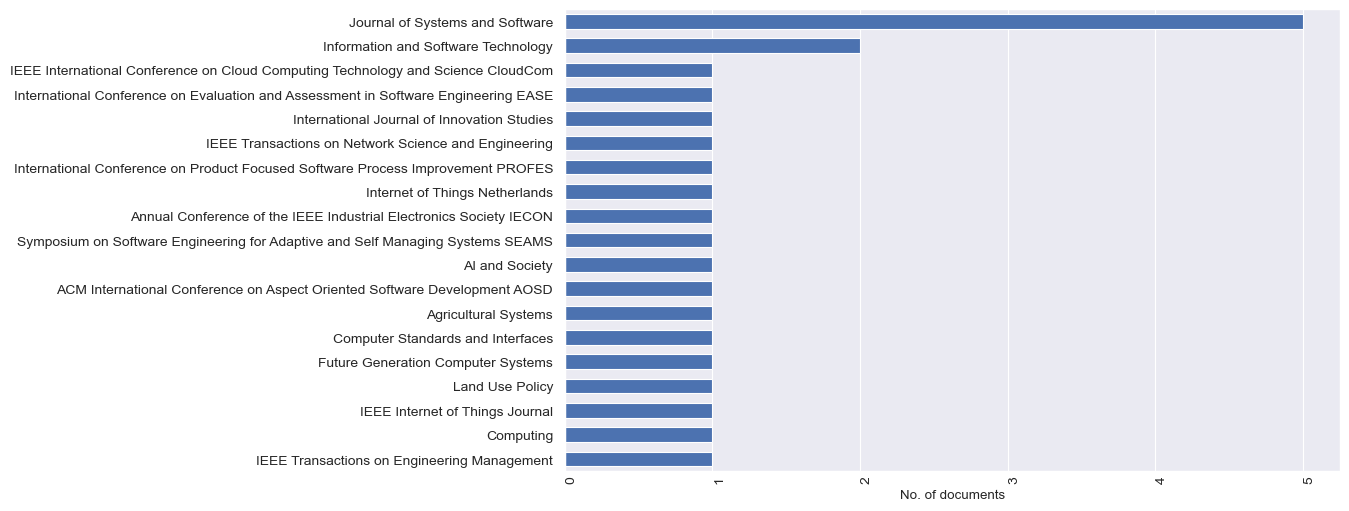

In [41]:
# This names are long, which is why a short abbreviation is provided.
import matplotlib.transforms

# plt.figure(4)
fig, ax = plt.subplots()
litstudy.plot_source_histogram(docs_filtered, vertical=False, label_rotation=0, bar_width=0.6, stacked=True, limit=25);
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.title('')

# rotates labels and aligns them horizontally to left 
#plt.setp( ax.xaxis.get_majorticklabels(), rotation=-90, ha="left", rotation_mode="anchor")

plt.setp( ax.xaxis.get_majorticklabels(), rotation=90) 

# Create offset transform by 5 points in x direction
dx = 5/72.; dy = 5/72. 
offset = matplotlib.transforms.ScaledTranslation(dx, dy, fig.dpi_scale_trans)

# apply offset transform to all x ticklabels.
for label in ax.xaxis.get_majorticklabels():
    label.set_transform(label.get_transform() + offset)
    
plt.savefig('Results/SOTA_SECO_CPS_2025-4-17_11-4-34_Analysis_Final/' + str(filename) + '_04_plot_source_all_histogram.png', dpi=300, bbox_inches='tight', format="PNG")

import csv

pdStatVenue = litstudy.stats.compute_source_histogram(docs_filtered)
display(pdStatVenue)
pdStatVenue.to_csv('Results/SOTA_SECO_CPS_2025-4-17_11-4-34_Analysis_Final/' + str(filename) + '_04_Venues_all.csv')   

In [43]:
docs_journal_all = docs_bib.filter_docs(lambda d: d.source_type == 'Journal'  or d.id.doi == '10.1007/978-3-319-46508-1_13')
# print(len(docs_journal))

pattern_conf = ['conference','symposium','lecture notes','congress','Design, Automation and Test in Europe']
docs_conf_all = docs_bib.filter_docs(lambda d: (d.source_type == 'Conference Proceeding' or d.source_type == 'Book Series' or 
                                            d.id.doi == '10.24251/HICSS.2017.569') and
                                 (not d.id.doi == '10.1007/978-3-319-46508-1_13') and
                                 ( re.search(pattern_conf[0],str(d.publication_source),re.IGNORECASE) or 
                                   re.search(pattern_conf[1],str(d.publication_source),re.IGNORECASE) or 
                                   re.search(pattern_conf[2],str(d.publication_source),re.IGNORECASE) or
                                   re.search(pattern_conf[4],str(d.publication_source),re.IGNORECASE) or
                                   re.search('studies',str(d.publication_source),re.IGNORECASE) ) and
                                   (not re.search('workshop',str(d.publication_source),re.IGNORECASE)) and
                                   (not re.search('companion',str(d.publication_source),re.IGNORECASE)) )

doc_workshop_all = docs_bib.filter_docs(lambda d: (d.source_type == 'Conference Proceeding' or d.source_type == 'Book Series' or 
                                                  d.id.doi == '10.24251/HICSS.2017.569') and  
                                        (not d.id.doi == '10.1007/978-3-319-46508-1_13') and
                                        (re.search('workshop',str(d.publication_source),re.IGNORECASE) or
                                         re.search('companion',str(d.publication_source),re.IGNORECASE) or
                                         re.search('forum',str(d.publication_source),re.IGNORECASE) ) )

doc_book_all = docs_bib.filter_docs(lambda d: d.source_type == 'Book')

pattern_symp = ['symposium','']
docs_symp_all = docs_bib.filter_docs(lambda d: (d.source_type == 'Conference Proceeding' or d.source_type == 'Book Series' or 
                                            d.id.doi == '10.24251/HICSS.2017.569') and
                                 (not d.id.doi == '10.1007/978-3-319-46508-1_13') and
                                 re.search(pattern_symp[0],str(d.publication_source),re.IGNORECASE) and
                                   (not re.search('workshop',str(d.publication_source),re.IGNORECASE)) and
                                   (not re.search('conference',str(d.publication_source),re.IGNORECASE)) )

pattern_forum = ['forum','']
docs_forum_all = docs_bib.filter_docs(lambda d: (d.source_type == 'Conference Proceeding' or d.source_type == 'Book Series' or 
                                            d.id.doi == '10.24251/HICSS.2017.569') and
                                 (not d.id.doi == '10.1007/978-3-319-46508-1_13') and
                                 re.search(pattern_forum[0],str(d.publication_source),re.IGNORECASE) )

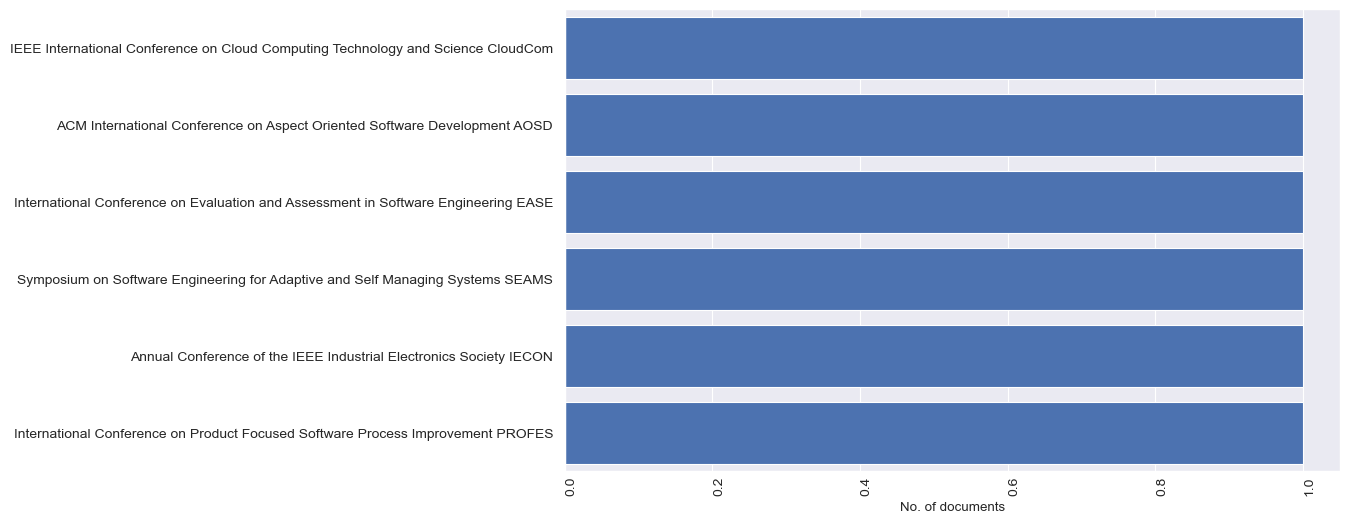

In [45]:
# plt.figure(5)
fig, ax = plt.subplots()
litstudy.plot_source_histogram(docs_conf_all, vertical=False, stacked=True, limit=25);
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.title('')

# rotates labels and aligns them horizontally to left 
#plt.setp( ax.xaxis.get_majorticklabels(), rotation=-90, ha="left", rotation_mode="anchor")

plt.setp( ax.xaxis.get_majorticklabels(), rotation=90) 

# Create offset transform by 5 points in x direction
dx = 5/72.; dy = 5/72. 
offset = matplotlib.transforms.ScaledTranslation(dx, dy, fig.dpi_scale_trans)

# apply offset transform to all x ticklabels.
for label in ax.xaxis.get_majorticklabels():
    label.set_transform(label.get_transform() + offset)
    
plt.savefig('Results/SOTA_SECO_CPS_2025-4-17_11-4-34_Analysis_Final/' + str(filename) + '_05_plot_source_conf_histogram.png', dpi=300, bbox_inches='tight', format="PNG")

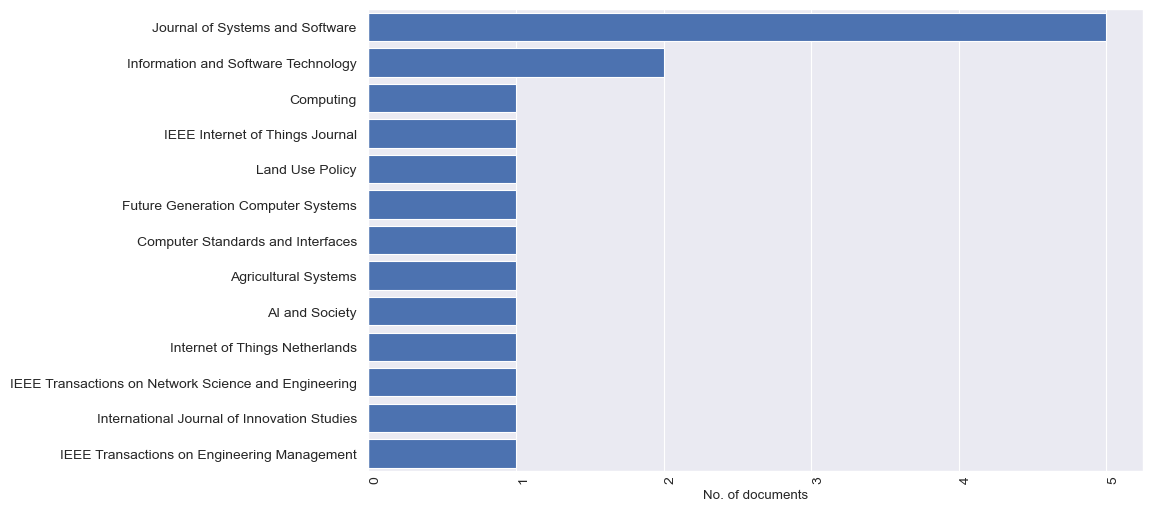

In [47]:
# plt.figure(6)
fig, ax = plt.subplots()
litstudy.plot_source_histogram(docs_journal_all, vertical=False, stacked=True, limit=25);
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.title('')

# rotates labels and aligns them horizontally to left 
#plt.setp( ax.xaxis.get_majorticklabels(), rotation=-90, ha="left", rotation_mode="anchor")

plt.setp( ax.xaxis.get_majorticklabels(), rotation=90) 

# Create offset transform by 5 points in x direction
dx = 5/72.; dy = 5/72. 
offset = matplotlib.transforms.ScaledTranslation(dx, dy, fig.dpi_scale_trans)

# apply offset transform to all x ticklabels.
for label in ax.xaxis.get_majorticklabels():
    label.set_transform(label.get_transform() + offset)
    
plt.savefig('Results/SOTA_SECO_CPS_2025-4-17_11-4-34_Analysis_Final/' + str(filename) + '_06_plot_source_journal_histogram.png', dpi=300, bbox_inches='tight', format="PNG")

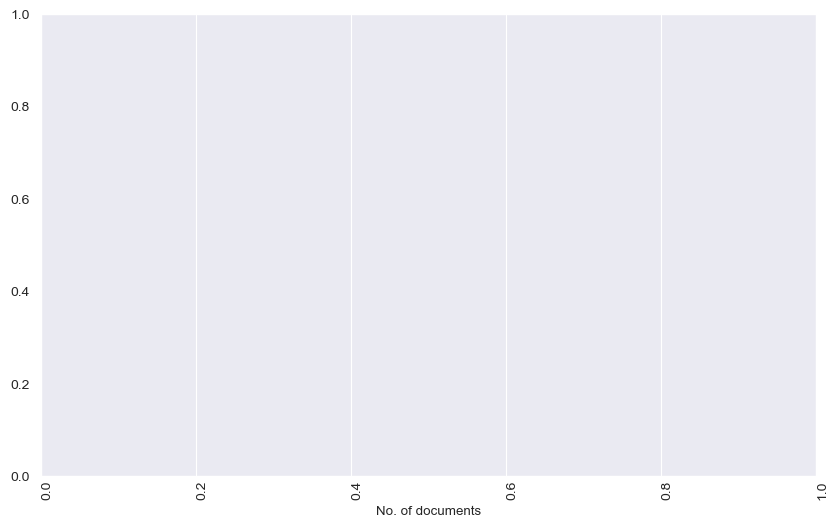

In [49]:
# plt.figure(7)
fig, ax = plt.subplots()
litstudy.plot_source_histogram(doc_workshop_all, vertical=False, stacked=True, limit=50);
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.title('')

# rotates labels and aligns them horizontally to left 
#plt.setp( ax.xaxis.get_majorticklabels(), rotation=-90, ha="left", rotation_mode="anchor")

plt.setp( ax.xaxis.get_majorticklabels(), rotation=90) 

# Create offset transform by 5 points in x direction
dx = 5/72.; dy = 5/72. 
offset = matplotlib.transforms.ScaledTranslation(dx, dy, fig.dpi_scale_trans)

# apply offset transform to all x ticklabels.
for label in ax.xaxis.get_majorticklabels():
    label.set_transform(label.get_transform() + offset)
    
plt.savefig('Results/SOTA_SECO_CPS_2025-4-17_11-4-34_Analysis_Final/' + str(filename) + '_07_plot_source_workshop_histogram.png', dpi=300, bbox_inches='tight', format="PNG")

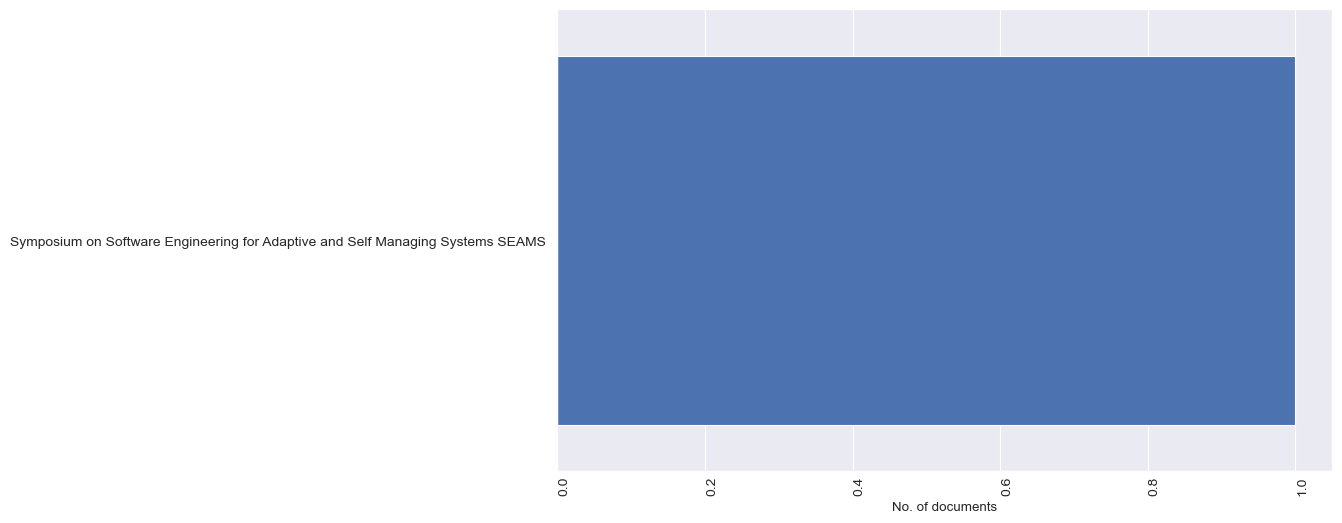

In [51]:
# plt.figure(8)
fig, ax = plt.subplots()
litstudy.plot_source_histogram(docs_symp_all, vertical=False, stacked=True, limit=25);
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.title('')

# rotates labels and aligns them horizontally to left 
#plt.setp( ax.xaxis.get_majorticklabels(), rotation=-90, ha="left", rotation_mode="anchor")

plt.setp( ax.xaxis.get_majorticklabels(), rotation=90) 

# Create offset transform by 5 points in x direction
dx = 5/72.; dy = 5/72. 
offset = matplotlib.transforms.ScaledTranslation(dx, dy, fig.dpi_scale_trans)

# apply offset transform to all x ticklabels.
for label in ax.xaxis.get_majorticklabels():
    label.set_transform(label.get_transform() + offset)
    
plt.savefig('Results/SOTA_SECO_CPS_2025-4-17_11-4-34_Analysis_Final/' + str(filename) + '_08_plot_source_symposium_histogram.png', dpi=300, bbox_inches='tight', format="PNG")

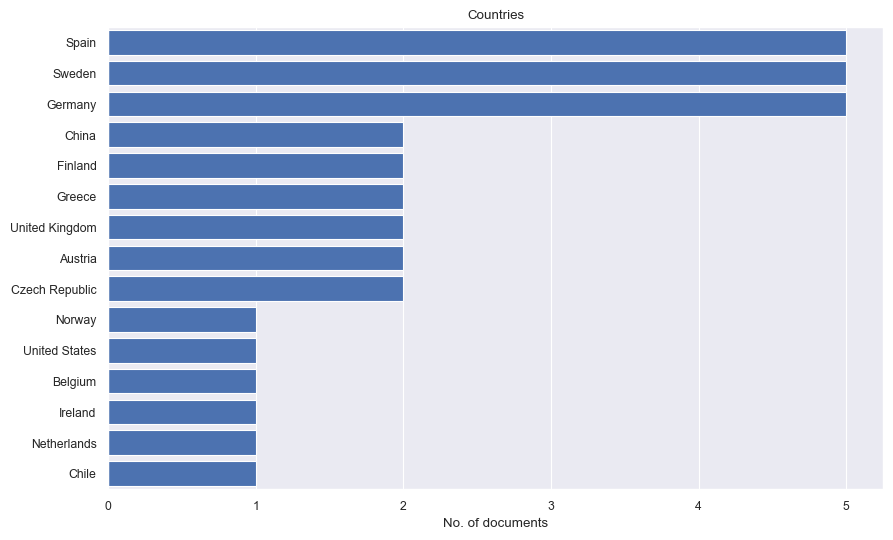

In [53]:
litstudy.plot_country_histogram(docs_filtered, limit=15);

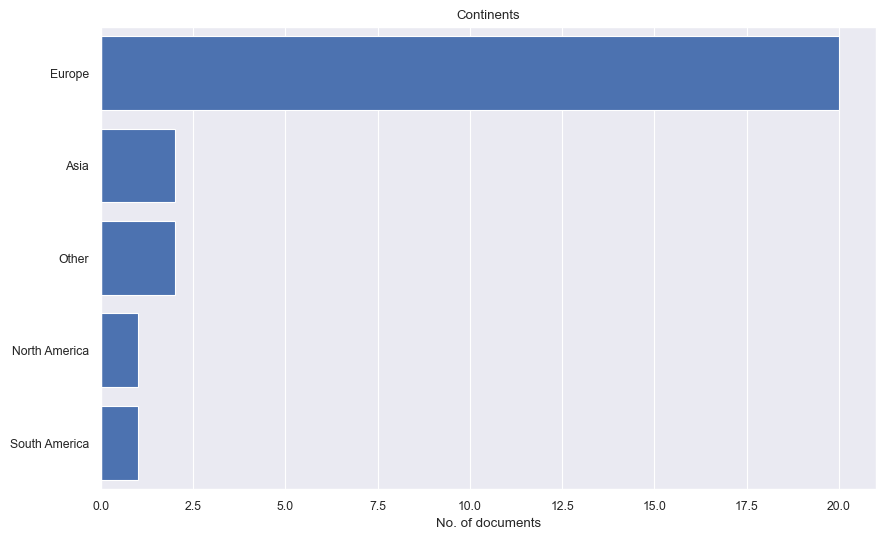

In [55]:
litstudy.plot_continent_histogram(docs_filtered);

# Selected Paper Network Analysis
Litstudy Network analysis

In [57]:
################################ CITATION NETWORK ###############################################
litstudy.plot_network(litstudy.build_citation_network(docs_filtered), smooth_edges=None, max_node_size=25, min_node_size=5, file_name='Results/SOTA_SECO_CPS_2025-4-17_11-4-34_Analysis_Final/' + str(filename) + '_09_network_full.html')

Results/SOTA_SECO_CPS_2025-4-17_11-4-34_Analysis_Final/SOTA_SECO_CPS_2025-5-15_11-7-15_09_network_full.html


In [59]:
import networkx as nx

bb_full = litstudy.build_citation_network(docs_filtered)

In [61]:
index = 0
data = []

while index < len(bb_full.nodes):
    References = 0
    RefID = ''
    CitedBy = 0
    CitedID = ''
    
    print('Paper', index)
    print('Title:', bb_full.nodes[index].get('title'))
    print('Degree:', bb_full.degree[index])
    print('\n')
    
    for idx in range(len(bb_full.out_edges(index))):
        edgeOut = list(bb_full.out_edges(index))[idx]
        print('Reference Paper:', edgeOut[1])
        RefID = RefID + '<' + str(edgeOut[1]) + '>'
        print('Title:', bb_full.nodes[edgeOut[1]].get('title'))
        
        References += 1
    
    print('References:', References)
    print('\n')
    
    for idx in range(len(bb_full.in_edges(index))):
        edgeIn = list(bb_full.in_edges(index))[idx]
        print('Cited by Paper:', edgeIn[0])
        CitedID = CitedID + '<' + str(edgeIn[0]) + '>'
        print(CitedID)
        print('Title:', bb_full.nodes[edgeIn[0]].get('title'))
        CitedBy += 1
    
    print('Citations:', CitedBy)
    print('\n')
    
    data.append({'Paper': index, 'Title': bb_full.nodes[index].get('title'), 'Degree': bb_full.degree[index], 'ReferencesID': RefID, 'TotRef': References, 'CitedByID': CitedID, 'TotCit': CitedBy})
        
    index += 1
    
# Saving first group of data to a single excel file
df = pd.DataFrame(data, columns=['Paper', 'Title', 'Degree', 'ReferencesID', 'TotRef', 'CitedByID', 'TotCit'])

df.to_excel('Results/SOTA_SECO_CPS_2025-4-17_11-4-34_Analysis_Final/' + str(filename) + '_10_CitationGraphFull.xlsx', index=False)

Paper 0
Title: Models@run.time for creating in-cloud dynamic cyber-physical ecosystems
Degree: 0


References: 0


Citations: 0


Paper 1
Title: Modular verification of dynamically adaptive systems
Degree: 0


References: 0


Citations: 0


Paper 2
Title: Automated analysis of feature models: Quo vadis?
Degree: 0


References: 0


Citations: 0


Paper 3
Title: NLES: A novel lifetime extension scheme for safety-critical cyber-physical systems using SDN and NFV
Degree: 0


References: 0


Citations: 0


Paper 4
Title: Automotive software engineering: A systematic mapping study
Degree: 0


References: 0


Citations: 0


Paper 5
Title: Smart systems of innovation for smart places: Challenges in deploying digital platforms for co-creation and data-intelligence
Degree: 0


References: 0


Citations: 0


Paper 6
Title: Quality assurance in software ecosystems: A systematic literature mapping and research agenda
Degree: 3


Reference Paper: 20
Title: Characteristics of software ecosystems for 

In [67]:
######################################### COUPLING NETWORK ########################################
litstudy.plot_coupling_network(docs_filtered, max_edges=150, node_size=10, file_name='Results/SOTA_SECO_CPS_2025-4-17_11-4-34_Analysis_Final/' + str(filename) + '_11_co-network_full.html')

Results/SOTA_SECO_CPS_2025-4-17_11-4-34_Analysis_Final/SOTA_SECO_CPS_2025-5-15_11-7-15_11_co-network_full.html


In [69]:
import networkx as nx

bb_coup_full = litstudy.build_coupling_network(docs_filtered, max_edges=500)

In [71]:
coup = 0
coupID = ''
coupWeight = ''
    
index = 0
for idx in range(len(bb_coup_full.edges(index))):
        edgeOut = list(bb_coup_full.edges(index))[idx]
        print('Coupling Paper:', edgeOut[1])
        coupID = coupID + '<' + str(edgeOut[1]) + '>'
        print('coupID:',coupID)
        coupWeight = coupWeight + '<' + str(bb_coup_full.get_edge_data(index,edgeOut[1])) + '>'
        print('coupWeight:',coupWeight)
        print('Title:', bb_coup_full.nodes[edgeOut[1]].get('title'))
        coup += 1

In [73]:
import networkx as nx

bb_coup_full = litstudy.build_coupling_network(docs_filtered, max_edges=500)

# bb_coup_full.edges
#bb_coup_full.edges(1)
# bb_coup_full.get_edge_data(70,106)

index = 0
data = []
while index < len(bb_coup_full.nodes):
    print(bb_coup_full.edges(index))
    
    coup = 0
    coupID = ''
    coupWeight = ''
    
    print('Paper', index)
    print('Title:', bb_coup_full.nodes[index].get('title'))
    print('Degree:', bb_coup_full.degree[index])
    print('\n')
    
    for idx in range(len(bb_coup_full.edges(index))):
        edgeOut = list(bb_coup_full.edges(index))[idx]
        print('Coupling Paper:', edgeOut[1])
        coupID = coupID + '<' + str(edgeOut[1]) + '>'
        coupWeight = coupWeight + '<' + str(bb_coup_full.get_edge_data(index,edgeOut[1])) + '>'
        print('Title:', bb_coup_full.nodes[edgeOut[1]].get('title'))
        coup += 1
        
    print('Total Coupling Papers:', coup)
    print('\n')
    
    data.append({'Paper': index, 'Title': bb_coup_full.nodes[index].get('title'), 'Degree': bb_coup_full.degree[index], 'Coupling Paper': coupID, 'Total Coupling Papers': coup, 'Weight': coupWeight})
        
    index += 1
    
# Saving first group of data to a single excel file
df = pd.DataFrame(data, columns=['Paper','Title', 'Degree', 'Coupling Paper', 'Total Coupling Papers','Weight'])

df.to_excel('Results/SOTA_SECO_CPS_2025-4-17_11-4-34_Analysis_Final/' + str(filename) + '_12_Co-CitationGraphFull.xlsx', index=False)

[]
Paper 0
Title: Models@run.time for creating in-cloud dynamic cyber-physical ecosystems
Degree: 0


Total Coupling Papers: 0


[(1, 2)]
Paper 1
Title: Modular verification of dynamically adaptive systems
Degree: 1


Coupling Paper: 2
Title: Automated analysis of feature models: Quo vadis?
Total Coupling Papers: 1


[(2, 1), (2, 4), (2, 6), (2, 23)]
Paper 2
Title: Automated analysis of feature models: Quo vadis?
Degree: 4


Coupling Paper: 1
Title: Modular verification of dynamically adaptive systems
Coupling Paper: 4
Title: Automotive software engineering: A systematic mapping study
Coupling Paper: 6
Title: Quality assurance in software ecosystems: A systematic literature mapping and research agenda
Coupling Paper: 23
Title: On Autonomous Dynamic Software Ecosystems
Total Coupling Papers: 4


[]
Paper 3
Title: NLES: A novel lifetime extension scheme for safety-critical cyber-physical systems using SDN and NFV
Degree: 0


Total Coupling Papers: 0


[(4, 2), (4, 6), (4, 13), (4, 18), (

In [75]:
################################## TOPIC MODELING ###################################
corpus = litstudy.build_corpus(docs_filtered, remove_words=['state','art','international',
          'publishing','nature','switzerland','association','computing','rights','reserved',
        'owner','author','recent','years','enable','allows','introduce','existing','identify','efficient',
        'literature','respect','update','view','achieved','assessment'], max_tokens=10000, ngram_threshold=0.0001) # custom_bigrams=custom_big

In [77]:
index = 0
while index < len(corpus.dictionary): 
    first_key = list(corpus.dictionary.values())[index]
    print(first_key)
    index += 1 

applications
called
challenges
cloud
communication
context
create
cyber
cyber_physical
design
different
domain
dynamic
emerging
integration
models
physical
process
services
address
analyzed
changes
include
increasingly
number
potential
providing
requirements
analysis
areas
case
common
defined
engineering
evolution
future
industrial
lack
mapping
performing
product
research
software_systems
source
study
systematic
testing
architecture
control
decision
enabling
internet
internet_things
management
needed
resource
things
activities
elsevier
fundamental
important
mechanisms
presents
actors
collaboration
complex
data
digital
information
open
platform
smart
technologies
embedded
identified
interactions
software_ecosystems
users
level
practical
support
business
role
solutions
successful
interoperability
tools
main


In [79]:
len(corpus.frequencies)

24

In [32]:
indexFREQ = 0
while indexFREQ < len(corpus.frequencies): 
    # print('Paper:',indexFREQ)
    #print('Title:',docs_filtered[indexFREQ].title)
    word_key = list(corpus.frequencies)[indexFREQ]
    index = 0
    data = []
    while index < len(word_key): 
        word = list(corpus.dictionary.values())[(word_key[index][0])]
        #print('Word:',word,' Freq:',word_key[index][1])
        data.append({'Word': word,'Freq': word_key[index][1]})
        index += 1
    
    # Saving first group of data to a single excel file
    df = pd.DataFrame(data, columns=['Word', 'Freq'])

    # Saving first group of data to a single csv file
    df.to_csv('Results/docs/' + str(indexFREQ) + '_word_freq.csv')

    # Saving first group of data to a single excel file
    #df.to_excel('Results/' + filename_xlsx, index=False)
    
    indexFREQ += 1

In [33]:
df_corpus = litstudy.compute_word_distribution(corpus, limit=500).filter(like='_', axis=0).sort_index()
df_corpus
df_corpus.to_csv('Results/' + str(filename) + '_13_abstract_word_freq.csv')

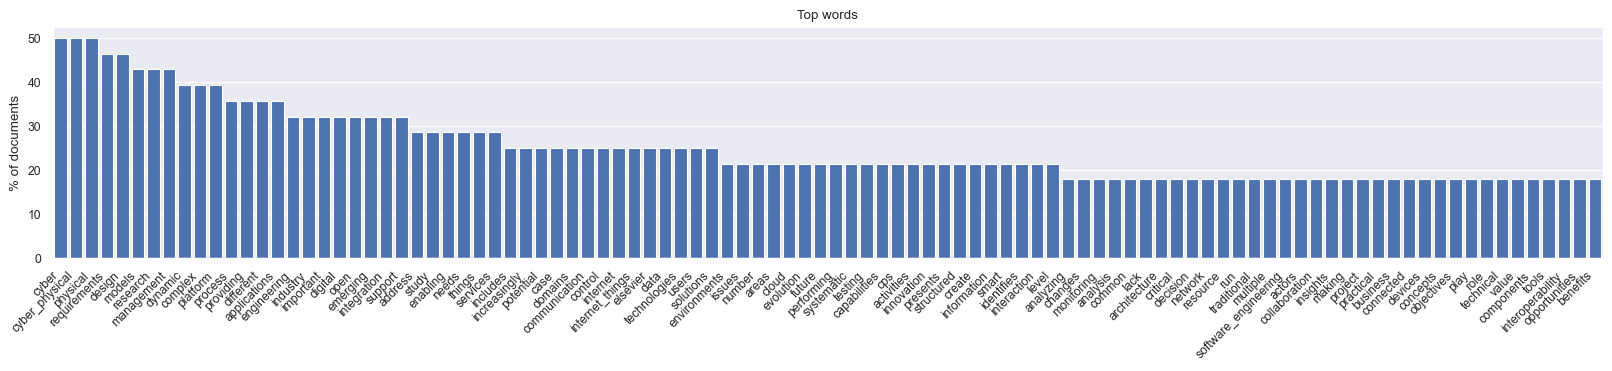

In [34]:
plt.figure(figsize=(20, 3))
litstudy.plot_word_distribution(corpus, title="Top words", limit=100, vertical=True, label_rotation=45) # limit=25,
plt.savefig('Results/' + str(filename) + '_14_plot_word_distribution_histogram.png', dpi=300, bbox_inches='tight', format="PNG")

In [36]:
###################### ##################
num_topics = 15
topic_model = litstudy.train_nmf_model(corpus, num_topics, max_iter=500)

In [37]:
import os
if os.path.exists('Results/' + str(filename) + '_15_Topics.txt'):
    os.remove('Results/' + str(filename) + '_15_Topics.txt')

for i in range(num_topics):
    print(f'Topic {i+1}:', topic_model.best_tokens_for_topic(i), file=open('Results/' + str(filename) + '_15_Topics.txt', 'a')) # a

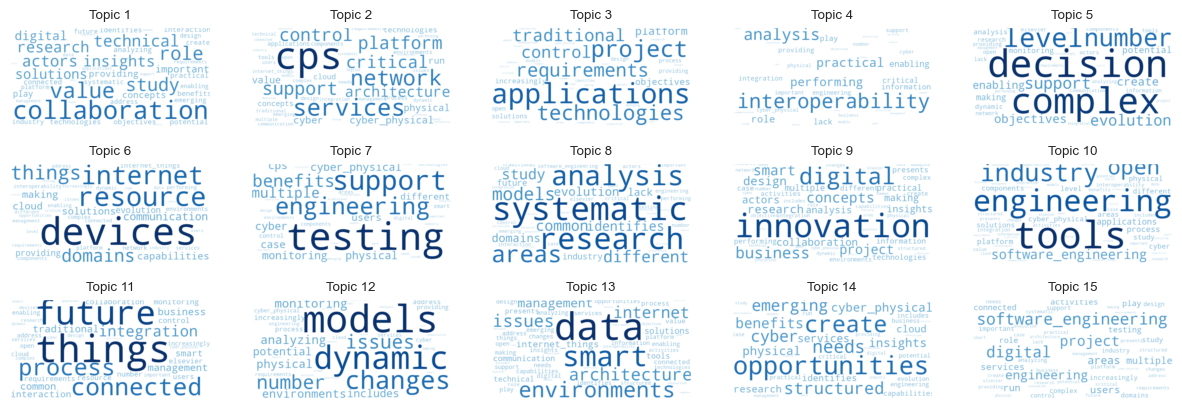

In [38]:
# Plot Topic Clouds
plt.figure(figsize=(15, 5))  # (25 topics: 25, 15), (15 Topics: 15, 5)
# litstudy.plot_topic_clouds(topic_model, ncols=5) 
litstudy.plot_topic_clouds(topic_model, ncols=5) 
plt.savefig('Results/' + str(filename) + '_16_plot_topic_clouds.png', dpi=300, bbox_inches='tight', format="PNG")

In [41]:
for doc_id in topic_model.best_topic_for_documents():
    index = int(doc_id)
    print(f'Topic n. {index} for: "', docs_filtered[index].title, '"')

Topic n. 11 for: " Assurance and certification of cyber–physical systems: The AMASS open source ecosystem "
Topic n. 7 for: " Elastic systems: Towards cyber-physical ecosystems of people, processes, and things "
Topic n. 1 for: " Automated analysis of feature models: Quo vadis? "
Topic n. 7 for: " Elastic systems: Towards cyber-physical ecosystems of people, processes, and things "
Topic n. 8 for: " Digital innovation ecosystems in agri-food: design principles and organizational framework "
Topic n. 7 for: " Elastic systems: Towards cyber-physical ecosystems of people, processes, and things "
Topic n. 12 for: " Quo vadis cyber-physical systems: Research areas of cyber-physical ecosystems "
Topic n. 10 for: " Internet of Things and Big Data: the disruption of the value chain and the rise of new software ecosystems "
Topic n. 8 for: " Digital innovation ecosystems in agri-food: design principles and organizational framework "
Topic n. 1 for: " Automated analysis of feature models: Quo va

In [47]:
for i in range(num_topics):
    topic_id = int(i)
    print(f'Topic n. {topic_id} for: "', topic_model.best_tokens_for_topic(topic_id), '"\n')
    for doc_id in topic_model.best_documents_for_topic(topic_id, limit=10):
        print(docs_filtered[int(doc_id)].title)
    print('\n')

Topic n. 0 for: " ['collaboration', 'value', 'role', 'study', 'technical'] "

Stakeholders collaborations, challenges and emerging concepts in digital twin ecosystems
Design of a multi-sided platform supporting CPS deployment in the automation market
Digital innovation ecosystems in agri-food: design principles and organizational framework
IoT-big data software ecosystems for smart cities sensing: challenges, open issues, and emerging solutions
Quality assurance in software ecosystems: A systematic literature mapping and research agenda
Automotive software engineering: A systematic mapping study
Internet of Things and Big Data: the disruption of the value chain and the rise of new software ecosystems
Advantages of Arrowhead Framework for the Machine Tooling Industry
Digital Transformation and Innovation and Business Ecosystems: A Bibliometric Analysis for Conceptual Insights and Collaborative Practices for Ecosystem Innovation
Assurance and certification of cyber–physical systems: The 